# Random Search Hyperparameter Tuning
**Models:** SGDClassifier vs LogisticRegression  
**Method:** RandomizedSearchCV  
**Objective:** Maximize F1 score (Toxic class)

In [9]:
""" import sys
!{sys.executable} -m pip install -r ../requirement.txt """

' import sys\n!{sys.executable} -m pip install -r ../requirement.txt '

## Step 1: Imports

In [10]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import contractions

from scipy.sparse import hstack, csr_matrix
from scipy.stats import loguniform, randint, uniform

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, f1_score,
    roc_auc_score, ConfusionMatrixDisplay
)

print('All imports OK')

All imports OK


## Step 2: Load & Clean Data

In [11]:
df = pd.read_csv('../data/train.csv')
df = df.drop(columns=['severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'])

def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = contractions.fix(text)
    text = re.sub(r'http\S+|www\S+', ' URL ', text)
    text = re.sub(r'[^a-z]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['raw_text']   = df['comment_text'].fillna('').astype(str)
df['clean_text'] = df['raw_text'].apply(clean_text)
df = df[df['clean_text'] != ''].copy()
df = df.drop_duplicates(subset=['clean_text']).reset_index(drop=True)

print(f'Dataset shape: {df.shape}')
print(df['toxic'].value_counts())

Dataset shape: (158194, 5)
toxic
0    143038
1     15156
Name: count, dtype: int64


## Step 3: Feature Engineering

In [12]:
PROFANITY_TERMS = [
    'fuck', 'fucking', 'shit', 'bitch', 'bastard', 'asshole', 'idiot', 'moron',
    'dumb', 'stupid', 'suck', 'crap', 'damn', 'jerk', 'loser', 'trash'
]
IDENTITY_TERMS = [
    'black', 'white', 'gay', 'lesbian', 'transgender', 'trans', 'muslim',
    'jewish', 'christian', 'hispanic', 'asian', 'woman', 'women', 'man', 'men'
]
SECOND_PERSON_TERMS = ['you', 'your', 'yours', 'yourself', 'u']
NEGATION_TERMS      = ['not', 'never', 'no', 'none', 'cannot', 'cant', 'do not']
NON_TOXIC_NEGATION_PATTERNS = [
    r'\bnot\s+(?:stupid|dumb|idiot|moron|trash|wrong|bad|terrible|awful|useless)\b',
    r'\bnot\s+(?:an|a)\s+(?:idiot|moron|loser|bastard|fool)\b',
    r'\bdo\s+not\s+(?:like|love|agree|hate|dislike|attack|insult|blame)\b',
    r'\bcannot\s+(?:hate|blame)\b',
    r'\bnot\s+trying\s+to\s+(?:attack|insult|offend)\b',
]
COMMON_SHORT_TOKENS = {
    'i','me','my','you','your','yours','yourself','it','this','that',
    'a','an','the','is','am','are','was','were','be','to','of','and'
}

def make_term_pattern(terms):
    escaped = sorted((re.escape(t) for t in terms), key=len, reverse=True)
    return re.compile(r'\b(?:' + '|'.join(escaped) + r')\b')

PROFANITY_PATTERN          = make_term_pattern(PROFANITY_TERMS)
IDENTITY_PATTERN           = make_term_pattern(IDENTITY_TERMS)
SECOND_PERSON_PATTERN      = make_term_pattern(SECOND_PERSON_TERMS)
NEGATION_PATTERN           = make_term_pattern(NEGATION_TERMS)
NON_TOXIC_NEGATION_PATTERN = re.compile('|'.join(NON_TOXIC_NEGATION_PATTERNS))

def count_pattern(text, pattern):
    return len(pattern.findall(str(text).lower()))
def repeated_characters_score(text):
    return len(re.findall(r'(.)\1{2,}', str(text).lower()))
def repeated_punctuation_count(text):
    return len(re.findall(r'([!?.,])\1+', str(text)))
def uppercase_ratio(text):
    letters = re.findall(r'[A-Za-z]', str(text))
    return sum(1 for c in letters if c.isupper()) / len(letters) if letters else 0.0
def short_unclear_without_toxic_signal(clean_text, profanity_count):
    tokens = str(clean_text).split()
    content_tokens = [t for t in tokens if t not in COMMON_SHORT_TOKENS]
    return int((len(tokens) < 3 or len(content_tokens) < 1) and profanity_count == 0)

df['Character Count']                   = df['raw_text'].apply(len)
df['Word Count']                        = df['clean_text'].apply(lambda x: len(x.split()))
df['Exclamation Count']                 = df['raw_text'].str.count('!')
df['Profanity Count']                   = df['clean_text'].apply(lambda x: count_pattern(x, PROFANITY_PATTERN))
df['Strong Toxic Signal Flag']          = (df['Profanity Count'] > 0).astype(int)
df['Second-person Pronoun Count']       = df['clean_text'].apply(lambda x: count_pattern(x, SECOND_PERSON_PATTERN))
df['Repeated Character Pattern Count'] = df['raw_text'].apply(repeated_characters_score)
df['Average Word Length']               = df['clean_text'].apply(
    lambda x: sum(len(w) for w in x.split()) / len(x.split()) if x.split() else 0)
df['Uppercase Ratio']                         = df['raw_text'].apply(uppercase_ratio)
df['Question Mark Count']                     = df['raw_text'].str.count(r'\?')
df['Repeated Punctuation Count']              = df['raw_text'].apply(repeated_punctuation_count)
df['Identity-group Term Count']               = df['clean_text'].apply(lambda x: count_pattern(x, IDENTITY_PATTERN))
df['URL Count']                               = df['raw_text'].str.count(r'http\S+|www\S+')
df['Negation Count']                          = df['clean_text'].apply(lambda x: count_pattern(x, NEGATION_PATTERN))
df['Non-toxic Negation Pattern Count']        = df['clean_text'].apply(lambda x: count_pattern(x, NON_TOXIC_NEGATION_PATTERN))
df['Short/Unclear Without Toxic Signal Flag'] = df.apply(
    lambda row: short_unclear_without_toxic_signal(row['clean_text'], row['Profanity Count']), axis=1)

print('Feature engineering done')

Feature engineering done


## Step 4: Train/Test Split & Vectorize

In [13]:
ENG_FEATURE_COLS = [
    'Character Count', 'Word Count', 'Exclamation Count',
    'Profanity Count', 'Strong Toxic Signal Flag',
    'Second-person Pronoun Count', 'Repeated Character Pattern Count',
    'Average Word Length', 'Uppercase Ratio', 'Question Mark Count',
    'Repeated Punctuation Count', 'Identity-group Term Count', 'URL Count',
    'Negation Count', 'Non-toxic Negation Pattern Count',
    'Short/Unclear Without Toxic Signal Flag'
]

X_raw, X_clean, X_eng, y = df['raw_text'], df['clean_text'], df[ENG_FEATURE_COLS], df['toxic']

(
    X_raw_train, X_raw_test,
    X_clean_train, X_clean_test,
    X_eng_train, X_eng_test,
    y_train, y_test
) = train_test_split(
    X_raw, X_clean, X_eng, y,
    test_size=0.2, random_state=42, stratify=y
)

word_vec = TfidfVectorizer(ngram_range=(1,2), max_features=10000, min_df=2, max_df=0.9, sublinear_tf=True)
X_word_train = word_vec.fit_transform(X_clean_train)
X_word_test  = word_vec.transform(X_clean_test)

char_vec = TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), max_features=10000, min_df=2, sublinear_tf=True)
X_char_train = char_vec.fit_transform(X_raw_train)
X_char_test  = char_vec.transform(X_raw_test)

scaler = StandardScaler(with_mean=False)
X_eng_train_scaled = scaler.fit_transform(X_eng_train.values)
X_eng_test_scaled  = scaler.transform(X_eng_test.values)

X_train = hstack([X_word_train, X_char_train, csr_matrix(X_eng_train_scaled)])
X_test  = hstack([X_word_test,  X_char_test,  csr_matrix(X_eng_test_scaled)])

print(f'Train: {len(y_train):,}  |  Test: {len(y_test):,}')
print(f'Feature matrix (train): {X_train.shape}')

Train: 126,555  |  Test: 31,639
Feature matrix (train): (126555, 20016)


## Step 5: Baseline (ก่อน Tuning)
> เทรน SGD และ LR ด้วย default params เพื่อใช้เปรียบเทียบ

In [14]:
# Baseline SGD
sgd_base = SGDClassifier(loss='modified_huber', class_weight='balanced', max_iter=100, random_state=42, n_jobs=-1)
sgd_base.fit(X_train, y_train)
f1_sgd_base = f1_score(y_test, sgd_base.predict(X_test))

# Baseline LR
lr_base = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, n_jobs=-1)
lr_base.fit(X_train, y_train)
f1_lr_base = f1_score(y_test, lr_base.predict(X_test))

print(f'Baseline SGD F1 : {f1_sgd_base:.4f}')
print(f'Baseline LR  F1 : {f1_lr_base:.4f}')

d:\Code\Repos\CPE232\project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Baseline SGD F1 : 0.6421
Baseline LR  F1 : 0.7379


## Step 6: Random Search — SGDClassifier

| Parameter | Distribution | ความหมาย |
|-----------|-------------|----------|
| `alpha` | `loguniform(1e-5, 1e-1)` | Regularization strength |
| `penalty` | `['l2','l1','elasticnet']` | ประเภท regularization |
| `class_weight` | 6 ตัวเลือก | น้ำหนัก toxic class |
| `max_iter` | `randint(50, 300)` | จำนวนรอบเรียนรู้ |
| `tol` | `loguniform(1e-5, 1e-2)` | Convergence threshold |
| `l1_ratio` | `uniform(0.05, 0.90)` | สัดส่วน L1 (เฉพาะ elasticnet) |

In [15]:
ran_n_inter = 20
k_folds_n_splits = 5

cv = StratifiedKFold(n_splits=k_folds_n_splits, shuffle=True, random_state=42)


sgd_param_dist = {
    'alpha':        loguniform(1e-5, 1e-1),
    'penalty':      ['l2', 'l1', 'elasticnet'],
    'class_weight': ['balanced', {0:1,1:2}, {0:1,1:3}, {0:1,1:5}, {0:1,1:7}, {0:1,1:10}],
    'max_iter':     randint(50, 300),
    'tol':          loguniform(1e-5, 1e-2),
    'l1_ratio':     uniform(0.05, 0.90),
}

sgd_rs = RandomizedSearchCV(
    SGDClassifier(loss='modified_huber', random_state=42, n_jobs=None),
    param_distributions=sgd_param_dist,
    n_iter=ran_n_inter,
    scoring='f1',
    cv=cv,
    refit=True,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print(f'SGD Random Search ({ran_n_inter} iter x {k_folds_n_splits}-fold)...')
sgd_rs.fit(X_train, y_train)

print(f'\nBest CV F1  : {sgd_rs.best_score_:.4f}')
print(f'Best Params : {sgd_rs.best_params_}')

SGD Random Search (20 iter x 5-fold)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best CV F1  : 0.7370
Best Params : {'alpha': np.float64(0.0007742116473996246), 'class_weight': {0: 1, 1: 7}, 'l1_ratio': np.float64(0.9245408858501935), 'max_iter': 180, 'penalty': 'l2', 'tol': np.float64(0.0014628121654892817)}


## Step 7: Random Search — LogisticRegression

| Parameter | Distribution | ความหมาย |
|-----------|-------------|----------|
| `C` | `loguniform(1e-3, 1e2)` | Inverse regularization (C สูง = regularize น้อย) |
| `penalty` | `['l2','l1']` | ประเภท regularization |
| `class_weight` | 6 ตัวเลือก | น้ำหนัก toxic class |
| `solver` | `['liblinear','saga']` | Algorithm (liblinear/saga รองรับ l1 ได้) |

In [16]:
lr_param_dist = {
    'C':            loguniform(1e-3, 1e2),
    'penalty':      ['l2', 'l1'],
    'class_weight': ['balanced', {0:1,1:2}, {0:1,1:3}, {0:1,1:5}, {0:1,1:7}, {0:1,1:10}],
    'solver':       ['liblinear', 'saga'],
}

lr_rs = RandomizedSearchCV(
    LogisticRegression(max_iter=1000, random_state=42, n_jobs=None),
    param_distributions=lr_param_dist,
    n_iter=ran_n_inter,
    scoring='f1',
    cv=cv,
    refit=True,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print(f'LR Random Search ({ran_n_inter} iter x 5-fold)...')
lr_rs.fit(X_train, y_train)

print(f'\nBest CV F1  : {lr_rs.best_score_:.4f}')
print(f'Best Params : {lr_rs.best_params_}')

LR Random Search (20 iter x 5-fold)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


d:\Code\Repos\CPE232\project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Code\Repos\CPE232\project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(



Best CV F1  : 0.7684
Best Params : {'C': np.float64(0.17885301261862016), 'class_weight': {0: 1, 1: 2}, 'penalty': 'l1', 'solver': 'liblinear'}


## Step 8: Evaluate & Compare ทั้งหมด

In [17]:
models = {
    'Baseline SGD': sgd_base,
    'Baseline LR':  lr_base,
    'Tuned SGD':    sgd_rs.best_estimator_,
    'Tuned LR':     lr_rs.best_estimator_,
}

print(f"{'Model':<15} {'F1':>8} {'ROC-AUC':>10}")
print('-' * 36)

scores = {}
for name, m in models.items():
    y_pred = m.predict(X_test)
    y_prob = m.predict_proba(X_test)[:, 1]
    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    scores[name] = {'f1': f1, 'auc': auc, 'pred': y_pred}
    print(f'{name:<15} {f1:>8.4f} {auc:>10.4f}')

Model                 F1    ROC-AUC
------------------------------------
Baseline SGD      0.6421     0.9367
Baseline LR       0.7379     0.9742
Tuned SGD         0.6466     0.9493
Tuned LR          0.7770     0.9679


In [18]:
# Classification Report ของ tuned models
for name in ['Tuned SGD', 'Tuned LR']:
    print(f'\n=== {name} ===')
    print(classification_report(y_test, scores[name]['pred'], target_names=['Not Toxic', 'Toxic']))


=== Tuned SGD ===
              precision    recall  f1-score   support

   Not Toxic       0.98      0.92      0.95     28608
       Toxic       0.52      0.85      0.65      3031

    accuracy                           0.91     31639
   macro avg       0.75      0.88      0.80     31639
weighted avg       0.94      0.91      0.92     31639


=== Tuned LR ===
              precision    recall  f1-score   support

   Not Toxic       0.97      0.98      0.98     28608
       Toxic       0.83      0.73      0.78      3031

    accuracy                           0.96     31639
   macro avg       0.90      0.86      0.88     31639
weighted avg       0.96      0.96      0.96     31639



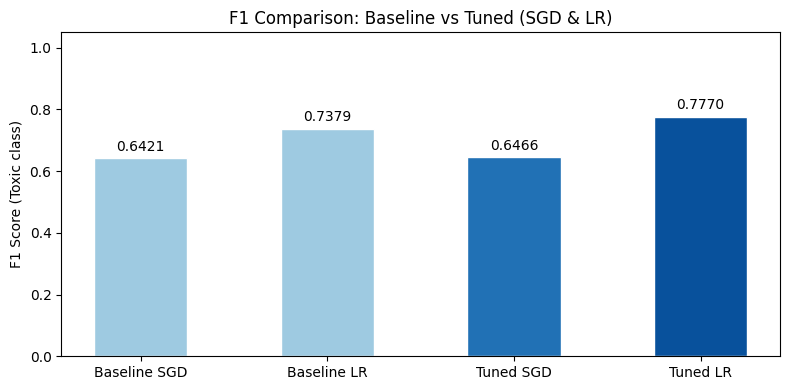

In [19]:
# Bar chart เปรียบเทียบ F1
names  = list(scores.keys())
f1s    = [scores[n]['f1'] for n in names]
colors = ['#9ecae1', '#9ecae1', '#2171b5', '#08519c']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(names, f1s, color=colors, edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='{:.4f}', padding=3, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel('F1 Score (Toxic class)')
ax.set_title('F1 Comparison: Baseline vs Tuned (SGD & LR)')
plt.tight_layout()
plt.show()

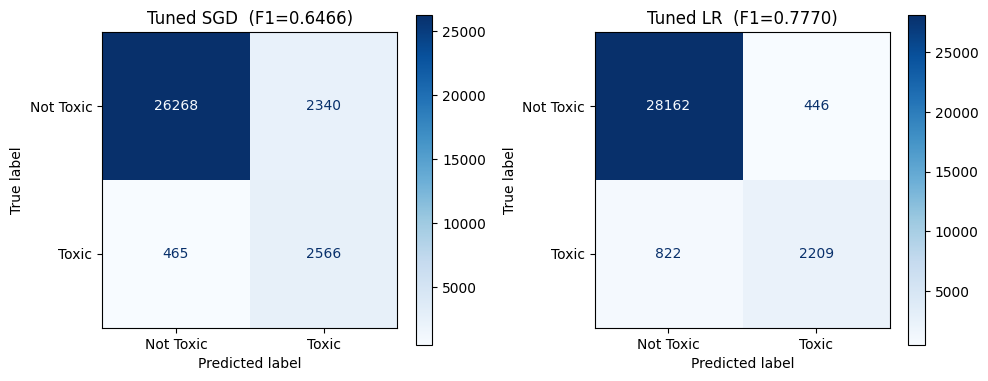

In [20]:
# Confusion Matrix ของ tuned models
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name in zip(axes, ['Tuned SGD', 'Tuned LR']):
    ConfusionMatrixDisplay.from_predictions(
        y_test, scores[name]['pred'],
        display_labels=['Not Toxic', 'Toxic'],
        cmap='Blues', ax=ax
    )
    ax.set_title(f'{name}  (F1={scores[name]["f1"]:.4f})')
plt.tight_layout()
plt.show()

## Step 9: Save Best Model Overall

In [21]:
# เลือก model ที่ F1 ดีที่สุดระหว่าง Tuned SGD กับ Tuned LR
best_name  = max(['Tuned SGD', 'Tuned LR'], key=lambda n: scores[n]['f1'])
best_model = models[best_name]

print(f'Best overall model : {best_name}')
print(f'Test F1            : {scores[best_name]["f1"]:.4f}')

with open('best_model_final.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print('Saved: best_model_final.pkl')

Best overall model : Tuned LR
Test F1            : 0.7770
Saved: best_model_final.pkl
